# Nathan Day

### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Problem 1

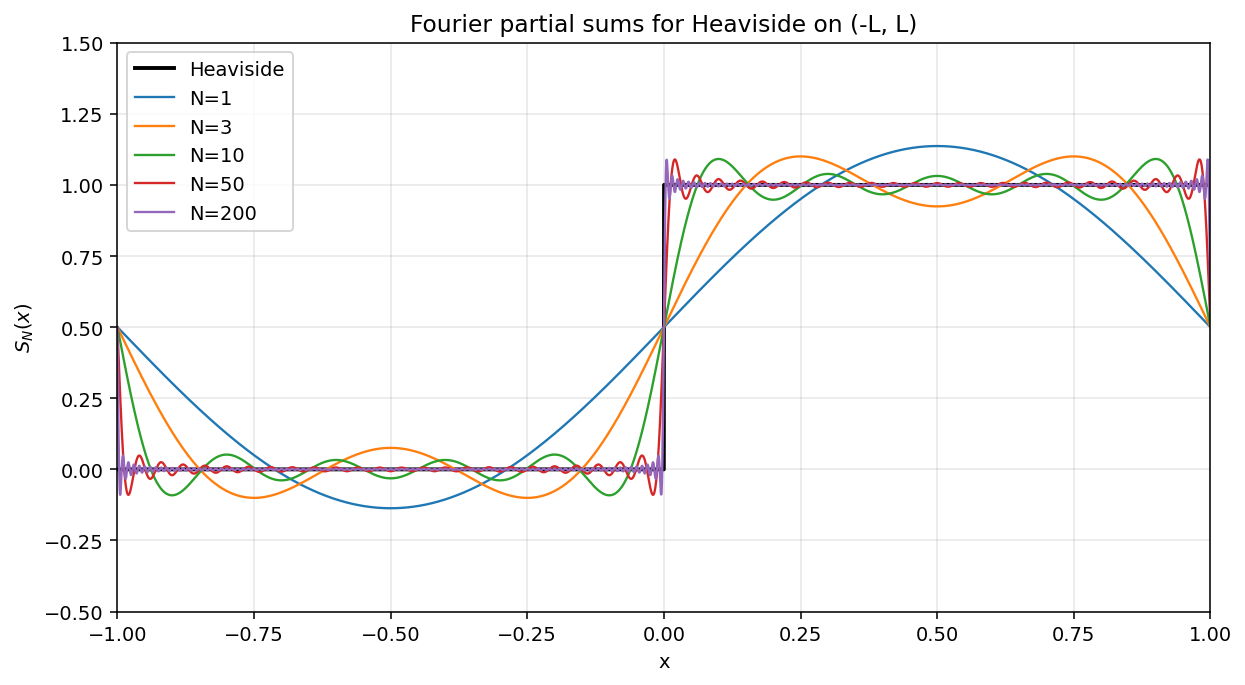

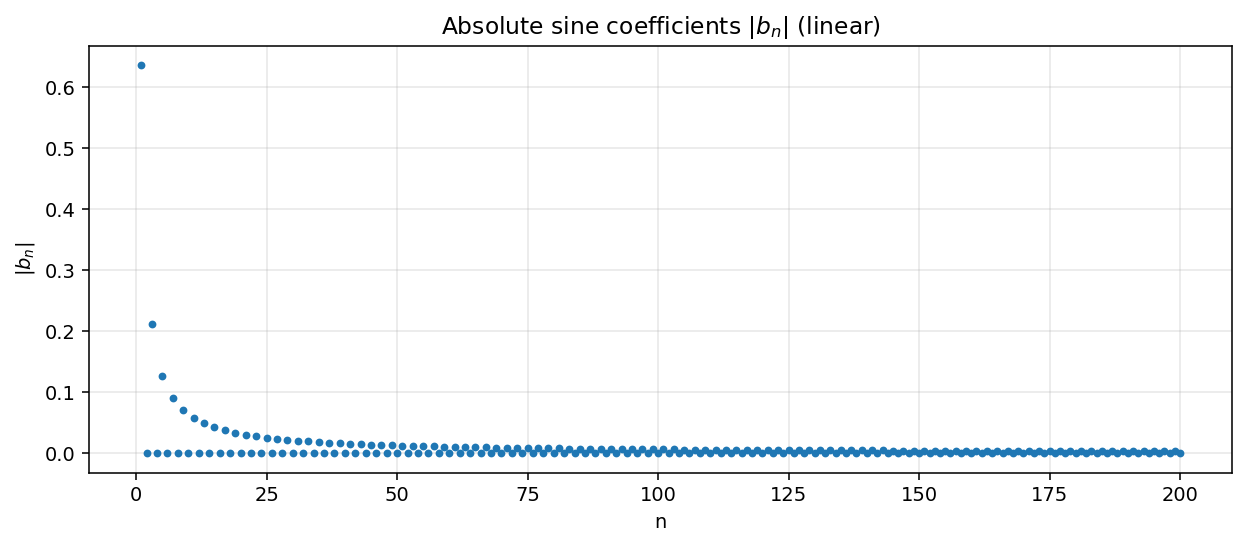

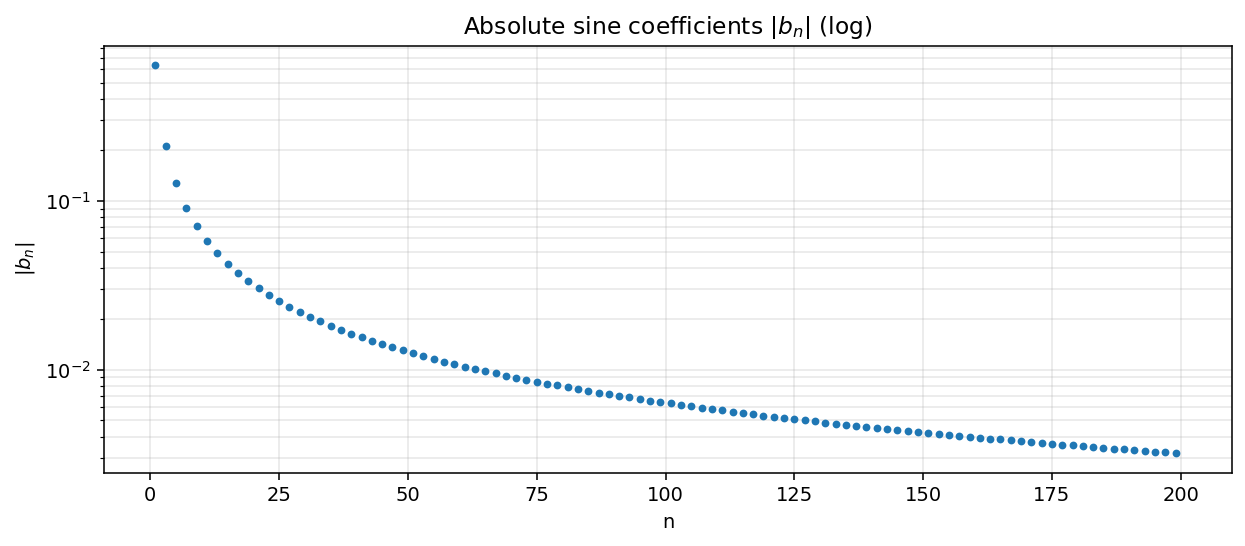

In [ ]:
# Parameters
L = 1.0
Ns = [1, 3, 10, 50, 200]
M = 4000
x = np.linspace(-L, L, M)

# Heaviside: 0 for x<0, 1 for x>0
H = (x > 0).astype(float)

Nmax = max(Ns)
n = np.arange(1, Nmax + 1, dtype=float)

a0 = 0.5
a = np.zeros(Nmax)
b = (1.0 / (n * np.pi)) * (1 - (-1)**n)  # 2/(nπ) for odd n, 0 for even n

# Plot convergence of partial sums
plt.figure(figsize=(9, 5), dpi=140)
plt.plot(x, H, "k", lw=2, label="Heaviside")

for N in Ns:
    k = np.arange(1, N + 1, dtype=float)  # 1..N

    S = a0 * np.ones_like(x)

    # Add cosine terms
    S += (a[:N][None, :] * np.cos((k[None, :] * np.pi * x[:, None]) / L)).sum(axis=1)

    # Add sine terms
    S += (b[:N][None, :] * np.sin((k[None, :] * np.pi * x[:, None]) / L)).sum(axis=1)

    plt.plot(x, S, lw=1.2, label=f"N={N}")

plt.xlim(-L, L)
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.title("Fourier partial sums for Heaviside on (-L, L)")
plt.xlabel("x")
plt.ylabel(r"$S_N(x)$")
plt.legend()
plt.tight_layout()

n_idx = np.arange(1, Nmax + 1)

plt.figure(figsize=(9, 4), dpi=140)
plt.plot(n_idx, np.abs(b), "o", markersize=3)
plt.grid(True, alpha=0.3)
plt.title(r"Absolute sine coefficients $|b_n|$ (linear)")
plt.xlabel("n")
plt.ylabel(r"$|b_n|$")
plt.tight_layout()

plt.figure(figsize=(9, 4), dpi=140)
plt.semilogy(n_idx, np.abs(b), "o", markersize=3)
plt.grid(True, which="both", alpha=0.3)
plt.title(r"Absolute sine coefficients $|b_n|$ (log)")
plt.xlabel("n")
plt.ylabel(r"$|b_n|$")
plt.tight_layout()

plt.show()

The partial sums converge to the Heaviside function away from the jump at x = 0, but oscillations remain still close to the discontinuity. These oscillations do not disappear as N increases. But instead, they become more I guess localized which shows the Gibbs phenomenon that we talked about in class. The coefficient plots show that only odd sine coefficients are nonzero and that their magnitudes decay like 1/n. This slow decay explains the slow convergence near the jump.

### Problem 2

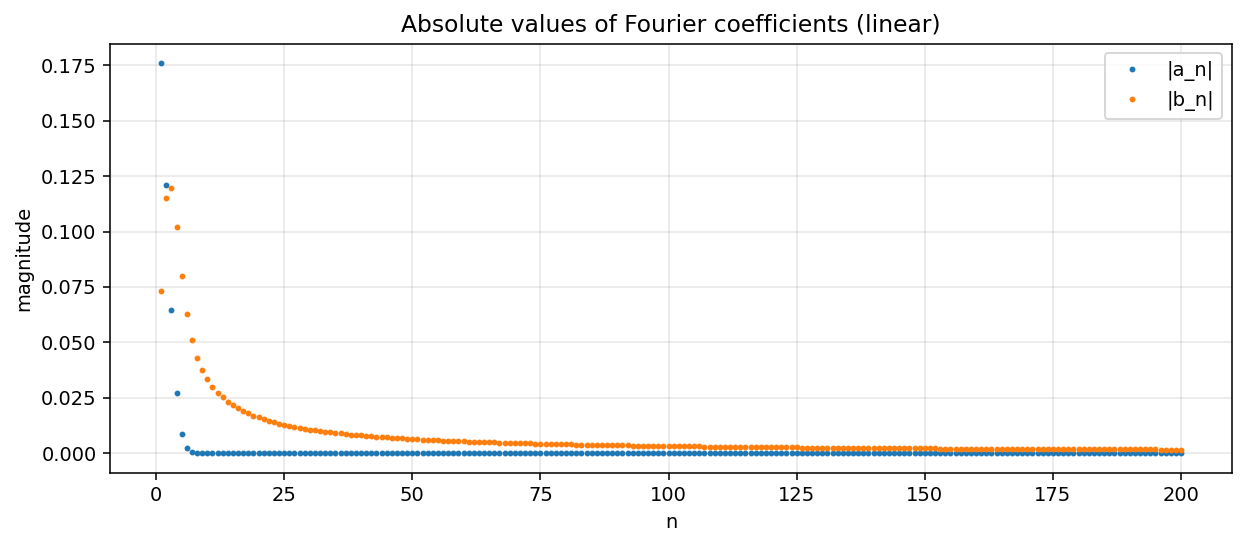

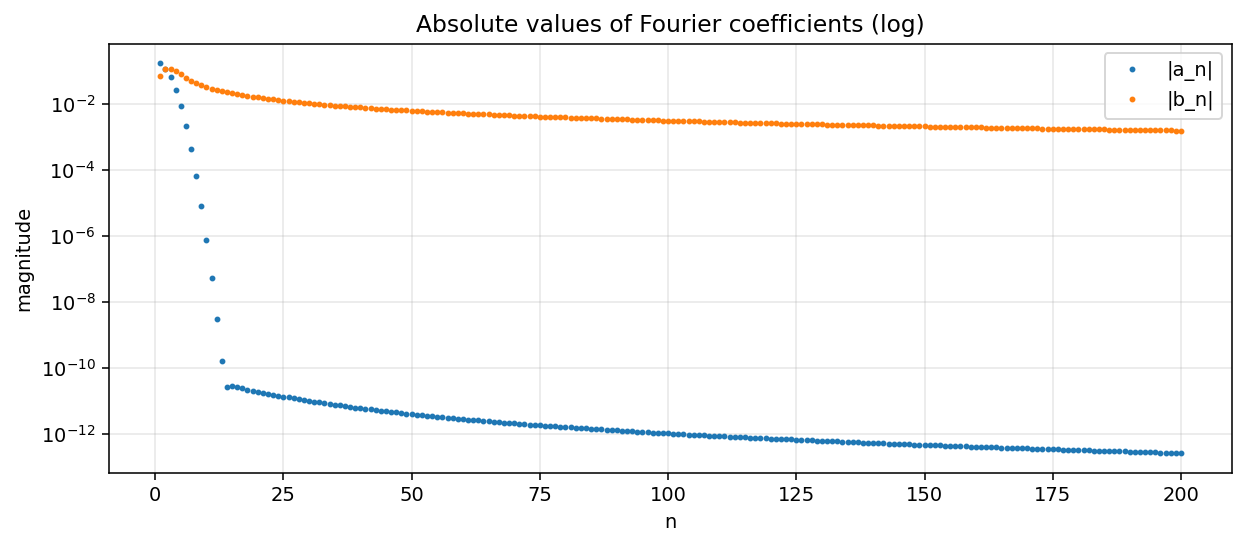

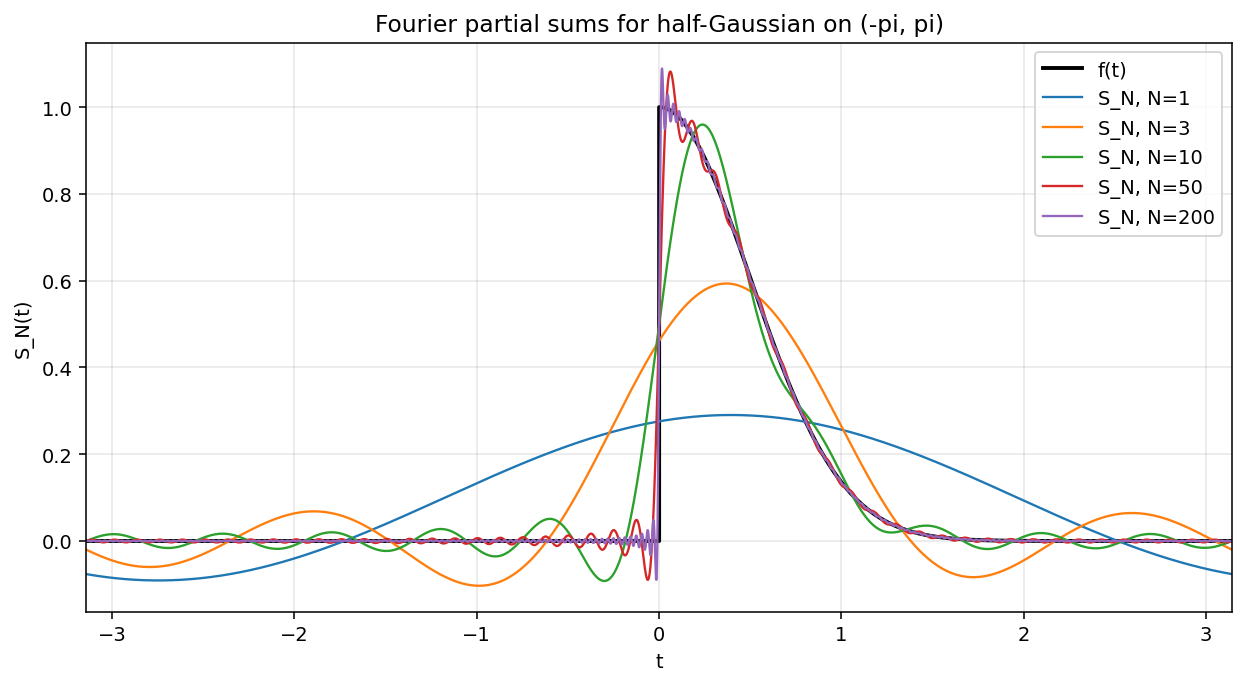

In [ ]:
# Parameters
N_coeff = 200
Ns = [1, 3, 10, 50, 200]

M = 200000
t = np.linspace(-np.pi, np.pi, M)

sigma = 0.5
f_t = np.zeros_like(t)
f_t[t >= 0] = np.exp(-(t[t >= 0]**2) / (2 * sigma**2))

a0 = (1.0 / (2 * np.pi)) * np.trapezoid(f_t, t)

n = np.arange(1, N_coeff + 1, dtype=float)
a = np.zeros(N_coeff)
b = np.zeros(N_coeff)

for k in range(1, N_coeff + 1):
    a[k - 1] = (1.0 / np.pi) * np.trapezoid(f_t * np.cos(k * t), t)
    b[k - 1] = (1.0 / np.pi) * np.trapezoid(f_t * np.sin(k * t), t)

# Present a plot of the coefficients
n_idx = np.arange(1, N_coeff + 1)

plt.figure(figsize=(9, 4), dpi=140)
plt.plot(n_idx, np.abs(a), ".", ms=4, label="|a_n|")
plt.plot(n_idx, np.abs(b), ".", ms=4, label="|b_n|")
plt.grid(True, alpha=0.3)
plt.title("Absolute values of Fourier coefficients (linear)")
plt.xlabel("n")
plt.ylabel("magnitude")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(9, 4), dpi=140)
plt.semilogy(n_idx, np.abs(a) + 1e-300, ".", ms=4, label="|a_n|")  # tiny offset avoids log(0) because I had this problem
plt.semilogy(n_idx, np.abs(b) + 1e-300, ".", ms=4, label="|b_n|")
plt.grid(True, which="both", alpha=0.3)
plt.title("Absolute values of Fourier coefficients (log)")
plt.xlabel("n")
plt.ylabel("magnitude")
plt.legend()
plt.tight_layout()

# Build partial sums and plot convergence
plt.figure(figsize=(9, 5), dpi=140)
plt.plot(t, f_t, "k", lw=2, label="f(t)")

for N in Ns:
    k = np.arange(1, N + 1, dtype=float)

    S = a0 * np.ones_like(t)
    S += (a[:N][None, :] * np.cos(k[None, :] * t[:, None])).sum(axis=1)
    S += (b[:N][None, :] * np.sin(k[None, :] * t[:, None])).sum(axis=1)

    plt.plot(t, S, lw=1.2, label=f"S_N, N={N}")

plt.xlim(-np.pi, np.pi)
plt.grid(True, alpha=0.3)
plt.title("Fourier partial sums for half-Gaussian on (-pi, pi)")
plt.xlabel("t")
plt.ylabel("S_N(t)")
plt.legend()
plt.tight_layout()

plt.show()

Near t = 0 the Fourier partial sums show oscillations and overshoot that persist as N increases. These oscillations become more localized around t = 0 but do not disappear, which is the Gibbs phenomenon. At the jump itself, the Fourier series converges to the average of the left and right limits. Since the function jumps from 0 to 1, the series approaches 0.5 at t = 0. Note that as N increases the Fourier coefficients converge to 0 on the linear scale.

### Problem 3

First amplitude C_1 = 12.0


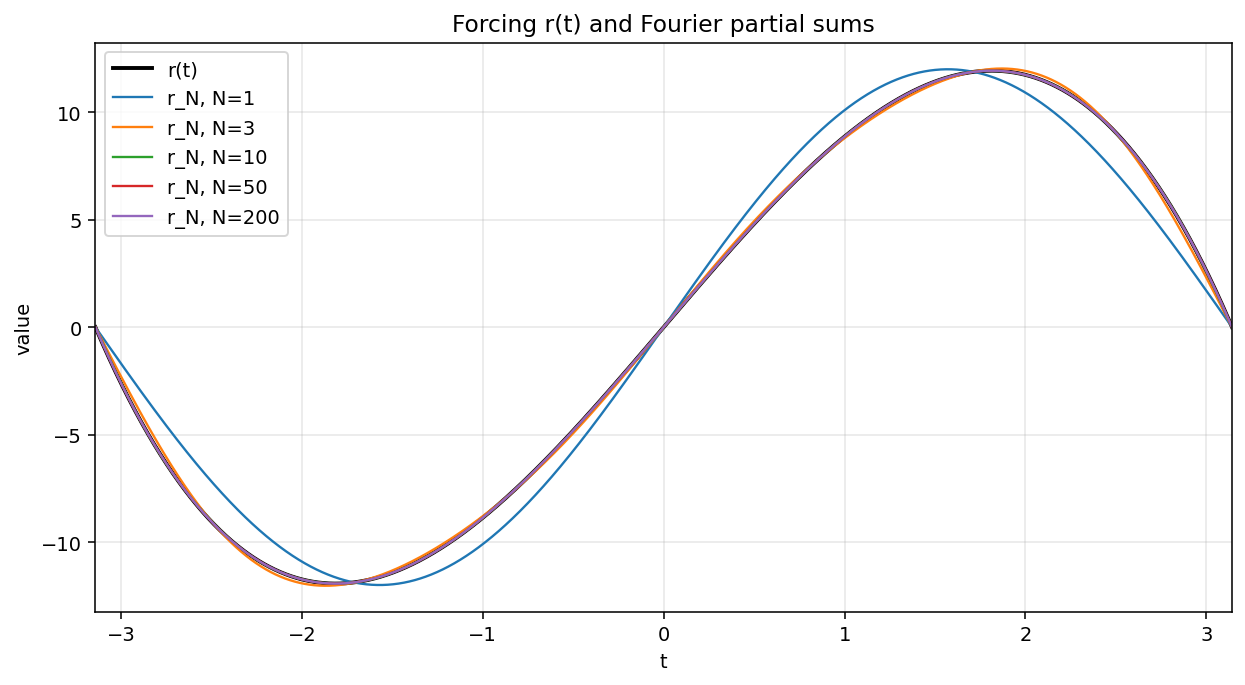

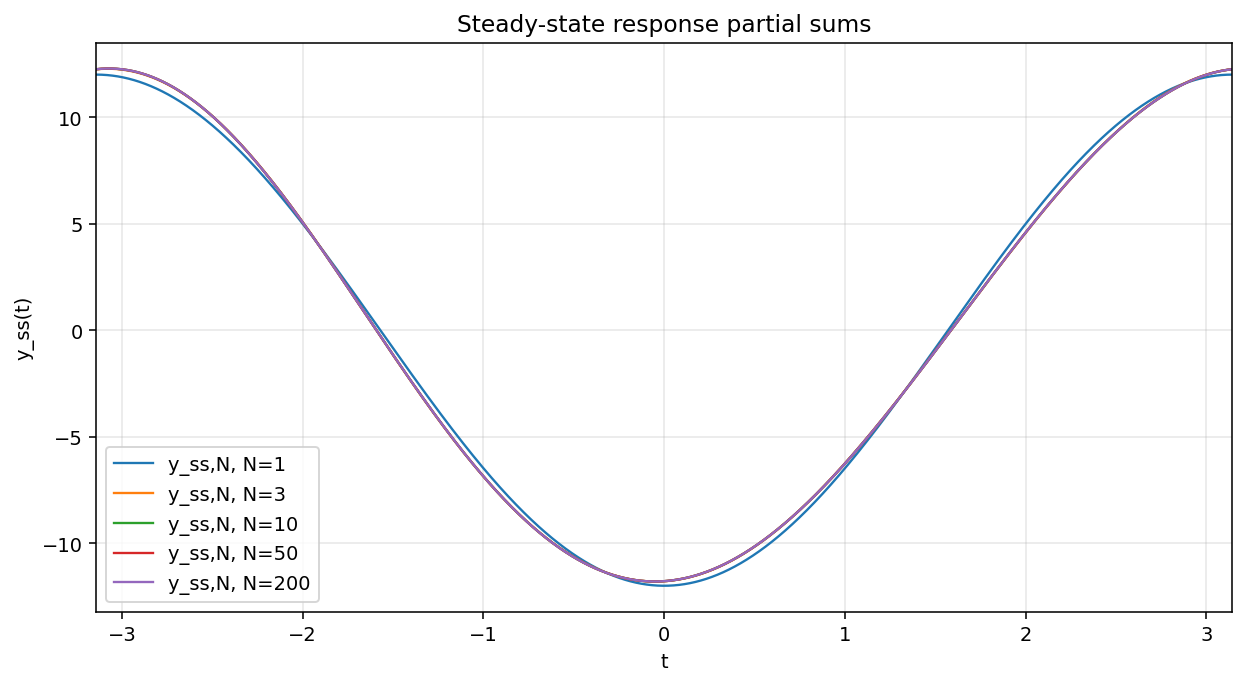

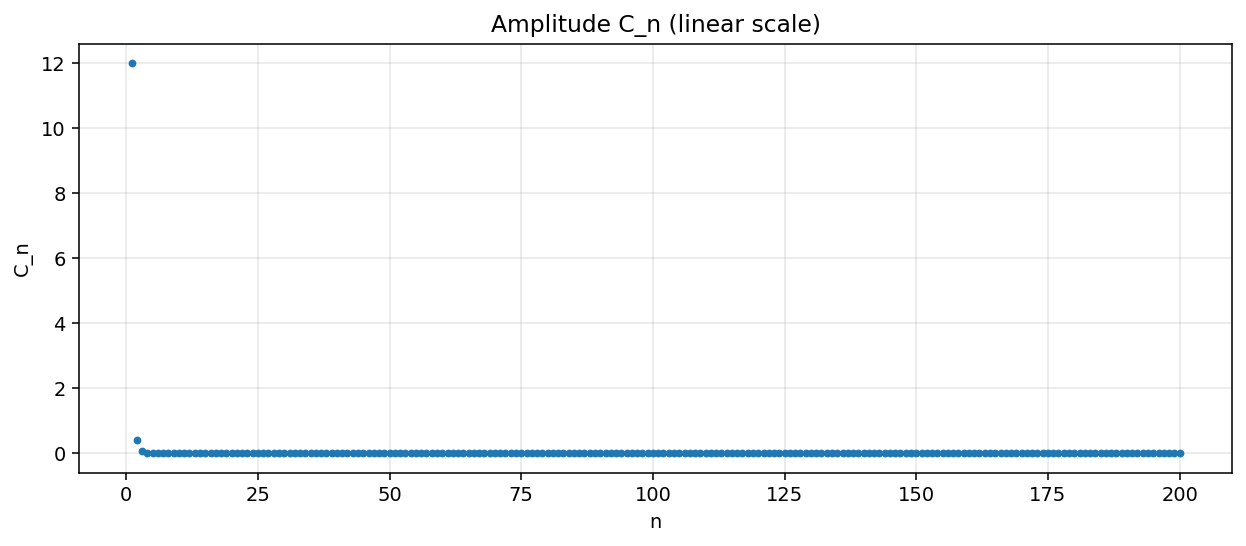

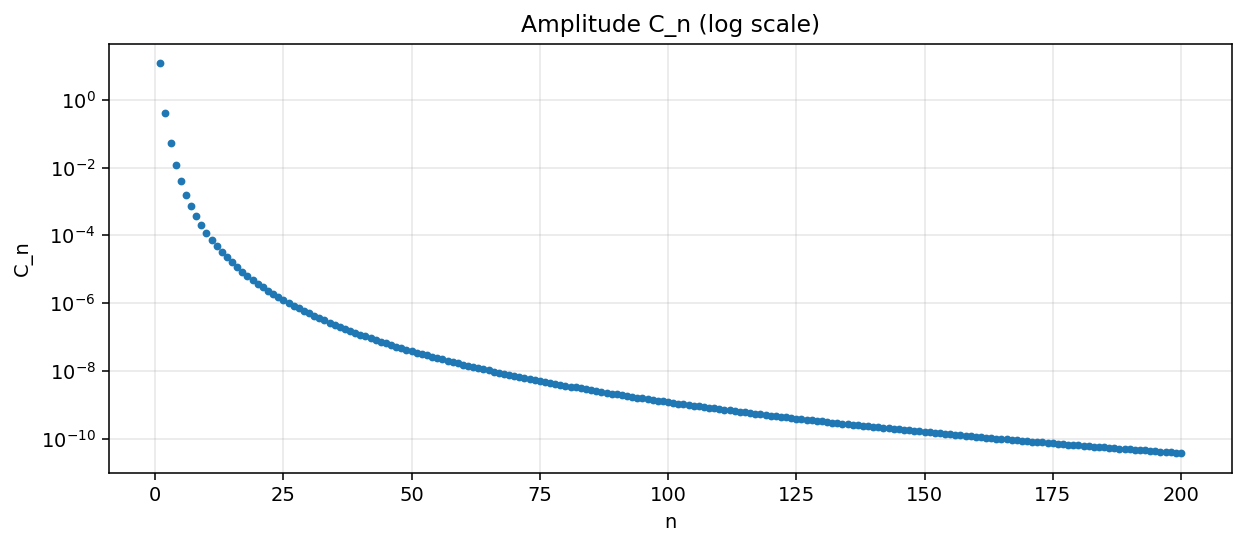

In [ ]:
# Parameters
c = 1.0
Nmax = 200
Ns = [1, 3, 10, 50, 200]

M = 4000
t = np.linspace(-np.pi, np.pi, M)

# Define forcing r(t) on (-pi, pi)
r = t * (np.pi**2 - t**2)


n = np.arange(1, Nmax + 1, dtype=float)

a0 = 0.0
a = np.zeros(Nmax)
b = 12.0 * ((-1.0) ** (n + 1.0)) / (n**3)

# (a) Plot forcing and its Fourier partial sums
plt.figure(figsize=(9, 5), dpi=140)
plt.plot(t, r, "k", lw=2, label="r(t)")

for N in Ns:
    k = np.arange(1, N + 1, dtype=float)
    rN = a0 * np.ones_like(t)
    rN += (a[:N][None, :] * np.cos(k[None, :] * t[:, None])).sum(axis=1)
    rN += (b[:N][None, :] * np.sin(k[None, :] * t[:, None])).sum(axis=1)
    plt.plot(t, rN, lw=1.2, label=f"r_N, N={N}")

plt.xlim(-np.pi, np.pi)
plt.grid(True, alpha=0.3)
plt.title("Forcing r(t) and Fourier partial sums")
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.tight_layout()

# (b) Steady-state coefficients A_n, B_n
# Seek the y_n = A_n cos(nt) + B_n sin(nt)
# For each n:
# (1 - n^2)A_n + (c n)B_n = a_n
# -(c n)A_n + (1 - n^2)B_n = b_n

# Solving this part...
# denom = (1 - n^2)^2 + (c n)^2
# A_n = ((1 - n^2)*a_n - (c n)*b_n)/denom
# B_n = ((c n)*a_n + (1 - n^2)*b_n)/denom

d = 1.0 - n**2
denom = d**2 + (c * n)**2

A = (d * a - (c * n) * b) / denom
B = ((c * n) * a + d * b) / denom

# Build and plot steady state partial sums
plt.figure(figsize=(9, 5), dpi=140)

for N in Ns:
    k = np.arange(1, N + 1, dtype=float)
    yN = np.zeros_like(t)
    yN += (A[:N][None, :] * np.cos(k[None, :] * t[:, None])).sum(axis=1)
    yN += (B[:N][None, :] * np.sin(k[None, :] * t[:, None])).sum(axis=1)
    plt.plot(t, yN, lw=1.2, label=f"y_ss,N, N={N}")

plt.xlim(-np.pi, np.pi)
plt.grid(True, alpha=0.3)
plt.title("Steady-state response partial sums")
plt.xlabel("t")
plt.ylabel("y_ss(t)")
plt.legend()
plt.tight_layout()

# (c) Amplitude plot C_n = sqrt(A_n^2 + B_n^2)
C = np.sqrt(A**2 + B**2)
n_idx = np.arange(1, Nmax + 1)

plt.figure(figsize=(9, 4), dpi=140)
plt.plot(n_idx, C, "o", markersize=3)
plt.grid(True, alpha=0.3)
plt.title("Amplitude C_n (linear scale)")
plt.xlabel("n")
plt.ylabel("C_n")
plt.tight_layout()

plt.figure(figsize=(9, 4), dpi=140)
plt.semilogy(n_idx, C, "o", markersize=3)
plt.grid(True, which="both", alpha=0.3)
plt.title("Amplitude C_n (log scale)")
plt.xlabel("n")
plt.ylabel("C_n")
plt.tight_layout()

# Very first value of C
print("First amplitude C_1 =", C[0])

plt.show()

The amplitude plot shows that the first mode dominates the response, with C₁ much larger than all the higher coefficients. After n = 1, the amplitudes decay rapidly as n increases, which is especially clear on the log plot. This indicates that the steady-state solution is mainly controlled by the lowest frequency mode. The large value of C₁ occurs because the forcing has a strong n = 1 component and the system responds most strongly at that frequency despite the presence of damping.